In [ ]:
!pip install onnxscript onnx kagglehub

In [1]:
# ==========================================
# 1. ติดตั้งไลบรารีที่จำเป็น & โหลด FreiHAND
# ==========================================
# 🌟 ติดตั้ง ONNX ดักไว้ตั้งแต่แรก จะได้ไม่ติดบั๊ก Restart ตอนจบ!

import kagglehub
import shutil
import os

print("\n⬇️ กำลังดาวน์โหลด FreiHAND Dataset (ไฟล์ใหญ่ อาจใช้เวลาสักครู่)...")
# โหลดผ่าน kagglehub
cached_path = kagglehub.dataset_download("danieldelro/freihand")

local_path = "/content/freihand"

# ย้ายไฟล์มาให้เห็นง่ายๆ
if not os.path.exists(local_path):
    print(f"📂 กำลังย้ายไฟล์ทั้งหมดมาที่หน้าต่างซ้ายมือ ({local_path})...")
    shutil.copytree(cached_path, local_path)

print(f"✅ พร้อมใช้งาน! ข้อมูลทั้งหมดถูกดึงมาอยู่ที่: {local_path}")


⬇️ กำลังดาวน์โหลด FreiHAND Dataset (ไฟล์ใหญ่ อาจใช้เวลาสักครู่)...
Using Colab cache for faster access to the 'freihand' dataset.
✅ พร้อมใช้งาน! ข้อมูลทั้งหมดถูกดึงมาอยู่ที่: /content/freihand


In [2]:
# ==========================================
# 2. แปลงพิกัด 3D เป็น 2D และสร้าง Bounding Box
# ==========================================
import json
import numpy as np
import glob
import os

def parse_freihand(path, max_images=32560):
    # ค้นหาไฟล์ json อัตโนมัติ (แม้จะซ้อนโฟลเดอร์อยู่)
    xyz_path = glob.glob(f"{path}/**/training_xyz.json", recursive=True)[0]
    k_path = glob.glob(f"{path}/**/training_K.json", recursive=True)[0]

    # หาโฟลเดอร์รูปภาพ (ปกติจะอยู่คู่กับโฟลเดอร์ json)
    img_dir = os.path.join(os.path.dirname(xyz_path), 'training', 'rgb')

    with open(xyz_path, 'r') as f: xyz_list = json.load(f)
    with open(k_path, 'r') as f: K_list = json.load(f)

    records = []
    print(f"⚙️ กำลังคำนวณและแปลงพิกัดมือ 21 จุด...")

    # ดึงมาแค่ 32,560 รูปแรก
    for i in range(min(len(xyz_list), max_images)):
        img_name = f"{i:08d}.jpg"
        img_path = os.path.join(img_dir, img_name)
        if not os.path.exists(img_path): continue

        xyz = np.array(xyz_list[i])
        K = np.array(K_list[i])

        # สมการโปรเจกชันแปลงโลก 3D เป็น 2D Pixel
        uv = np.matmul(K, xyz.T).T
        uv2d = uv[:, :2] / uv[:, -1:]

        # สร้าง Bounding Box โดยตีงกรอบจากพิกัดมือ
        min_x, min_y = np.min(uv2d[:, 0]), np.min(uv2d[:, 1])
        max_x, max_y = np.max(uv2d[:, 0]), np.max(uv2d[:, 1])

        records.append({
            "image_path": img_path,
            "keypoints": uv2d.flatten().tolist(),
            "bbox": [min_x, min_y, max_x, max_y]
        })

    return records

# โหลดจาก local path ที่เรากำหนดไว้ใน Cell 1
hand_records = parse_freihand("/content/freihand")

# แบ่ง Train 90% / Val 10%
split_idx = int(len(hand_records) * 0.9)
train_hand_records = hand_records[:split_idx]
val_hand_records = hand_records[split_idx:]

print(f"✅ เตรียมข้อมูลมือสำเร็จ!")
print(f"  - 📚 Train Set : {len(train_hand_records)} รูป")
print(f"  - 🎯 Val Set   : {len(val_hand_records)} รูป")

⚙️ กำลังคำนวณและแปลงพิกัดมือ 21 จุด...
✅ เตรียมข้อมูลมือสำเร็จ!
  - 📚 Train Set : 29304 รูป
  - 🎯 Val Set   : 3256 รูป


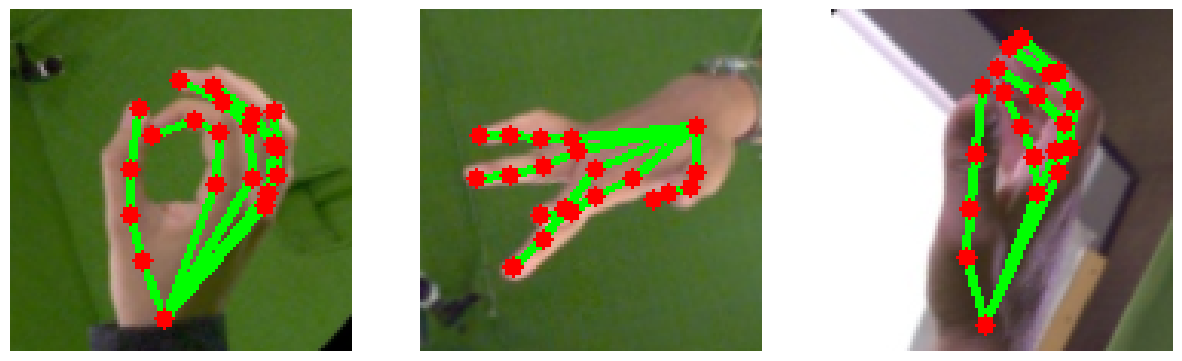

In [3]:
# ==========================================
# 3. สร้าง Dataset และเช็คความถูกต้อง (Visualization)
# ==========================================
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import cv2
import random
import multiprocessing
import matplotlib.pyplot as plt

class HandDataset(Dataset):
    def __init__(self, records, input_size=(112, 112), is_train=False):
        self.records = records
        self.input_size = input_size
        self.is_train = is_train
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2) if is_train else transforms.Lambda(lambda x: x),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        image = cv2.imread(record["image_path"])
        if image is None: return self.__getitem__((idx + 1) % len(self.records))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        x1, y1, x2, y2 = record["bbox"]
        w, h = x2 - x1, y2 - y1
        center_x, center_y = x1 + w/2, y1 + h/2
        kpts = np.array(record["keypoints"]).reshape(21, 2)

        # 🌟 สุ่มหมุนภาพมือ (Rotation Augmentation) เพื่อความทนทานตอนสตรีมจริง
        if self.is_train:
            angle = random.uniform(-45, 45) # มือหมุนได้เยอะกว่าหน้า
            M = cv2.getRotationMatrix2D((center_x, center_y), angle, 1.0)
            image = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))
            kpts = np.hstack([kpts, np.ones((21, 1))]).dot(M.T)

        # บังคับตัด Square Crop ป้องกันมือเบี้ยว
        size = max(w, h) * 1.5 # ขยายกว้างหน่อยเพราะนิ้วอาจจะตกขอบ
        x_min, y_min = max(0, int(center_x - size/2)), max(0, int(center_y - size/2))
        x_max, y_max = min(image.shape[1], int(center_x + size/2)), min(image.shape[0], int(center_y + size/2))

        cropped_img = image[y_min:y_max, x_min:x_max]
        if cropped_img.shape[0] == 0 or cropped_img.shape[1] == 0: return self.__getitem__((idx + 1) % len(self.records))
        cropped_img = cv2.resize(cropped_img, self.input_size)

        target_kpts = np.zeros((21, 2), dtype=np.float32)
        for i in range(21):
            target_kpts[i][0] = (kpts[i][0] - x_min) / (x_max - x_min)
            target_kpts[i][1] = (kpts[i][1] - y_min) / (y_max - y_min)

        img_tensor = self.transform(cropped_img)
        return img_tensor, torch.from_numpy(target_kpts.flatten()), cropped_img, target_kpts

train_hand_dataset = HandDataset(train_hand_records, is_train=True)
val_hand_dataset = HandDataset(val_hand_records, is_train=False)

num_cores = multiprocessing.cpu_count()
train_hand_loader = DataLoader(train_hand_dataset, batch_size=512, shuffle=True, num_workers=num_cores, pin_memory=True, drop_last=True)
val_hand_loader = DataLoader(val_hand_dataset, batch_size=512, shuffle=False, num_workers=num_cores, pin_memory=True)

# 📸 วาดโครงกระดูกมือให้ดูก่อนเทรน
def visualize_skeleton():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    connections = [(0,1), (1,2), (2,3), (3,4), (0,5), (5,6), (6,7), (7,8), (0,9), (9,10), (10,11), (11,12), (0,13), (13,14), (14,15), (15,16), (0,17), (17,18), (18,19), (19,20)]
    for i in range(3):
        _, _, img, kpts = train_hand_dataset[random.randint(0, len(train_hand_dataset)-1)]
        img_draw = img.copy()
        kpts_pixel = (kpts * 112).astype(int)
        for (u, v) in connections:
            cv2.line(img_draw, tuple(kpts_pixel[u]), tuple(kpts_pixel[v]), (0, 255, 0), 2)
        for pt in kpts_pixel:
            cv2.circle(img_draw, tuple(pt), 3, (255, 0, 0), -1)
        axes[i].imshow(img_draw)
        axes[i].axis('off')
    plt.show()

visualize_skeleton()

In [4]:
# ==========================================
# 4. โมเดล PFLD รุ่น XL (ขยายสมองเพิ่มความแม่นยำ)
# ==========================================
import torch.nn as nn
import math
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio):
        super().__init__()
        self.use_res_connect = stride == 1 and inp == oup
        hidden_dim = round(inp * expand_ratio)
        layers = []
        if expand_ratio != 1: layers.extend([nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False), nn.BatchNorm2d(hidden_dim), nn.ReLU(inplace=True)])
        layers.extend([nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False), nn.BatchNorm2d(hidden_dim), nn.ReLU(inplace=True), nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False), nn.BatchNorm2d(oup)])
        self.conv = nn.Sequential(*layers)
    def forward(self, x): return x + self.conv(x) if self.use_res_connect else self.conv(x)

class HandLandmarkModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 🌟 อัปเกรด: ขยายช่องสัญญาณจาก 64 -> 128
        self.conv1 = nn.Sequential(nn.Conv2d(3, 128, 3, 2, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True))
        self.conv2 = nn.Sequential(nn.Conv2d(128, 128, 3, 1, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True))
        self.block3 = nn.Sequential(InvertedResidual(128, 128, 2, 2), InvertedResidual(128, 128, 1, 2), InvertedResidual(128, 128, 1, 2), InvertedResidual(128, 128, 1, 2), InvertedResidual(128, 128, 1, 2))

        # 🌟 อัปเกรด: ขยายช่องสัญญาณจาก 128 -> 256
        self.block4 = InvertedResidual(128, 256, 2, 2)
        self.block5 = nn.Sequential(InvertedResidual(256, 256, 1, 4), InvertedResidual(256, 256, 1, 4), InvertedResidual(256, 256, 1, 4), InvertedResidual(256, 256, 1, 4), InvertedResidual(256, 256, 1, 4), InvertedResidual(256, 256, 1, 4))

        self.out1_branch = InvertedResidual(256, 32, 1, 2)
        self.out2_branch = nn.Sequential(nn.Conv2d(32, 64, 3, 2, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(True))
        self.out3_branch = nn.Sequential(nn.Conv2d(64, 256, 7, 1, 0, bias=False), nn.BatchNorm2d(256), nn.ReLU(True))

        self.avg_pool1 = nn.AvgPool2d(14)
        self.avg_pool2 = nn.AvgPool2d(7)

        # เชื่อมพิกัด 21 จุด (x, y) = 42 ออกมาเหมือนเดิม
        self.fc = nn.Linear(32 + 64 + 256, 21 * 2)

    def forward(self, x):
        x = self.conv2(self.conv1(x))
        x = self.block5(self.block4(self.block3(x)))
        out1 = self.out1_branch(x)
        out2 = self.out2_branch(out1)
        out3 = self.out3_branch(out2)
        multi_scale = torch.cat([self.avg_pool1(out1).view(x.size(0), -1), self.avg_pool2(out2).view(x.size(0), -1), out3.view(x.size(0), -1)], 1)
        return torch.sigmoid(self.fc(multi_scale))

class HandWingLoss(nn.Module):
    def __init__(self, w=10.0, epsilon=2.0):
        super().__init__()
        self.w, self.epsilon = w, epsilon
        self.c = w - w * math.log(1 + w / epsilon)
        weights = torch.ones(21, 2)
        fingertips = [4, 8, 12, 16, 20]
        for idx in fingertips: weights[idx, :] = 3.0
        self.register_buffer('weights', weights.view(1, 42))

    def forward(self, pred, target):
        x = torch.abs(pred - target) * 112.0
        loss = torch.where(x < self.w, self.w * torch.log(1 + x / self.epsilon), x - self.c)
        return (loss * self.weights).mean()

print("✅ โหลดสมอง Hand Model รุ่น XL (256-channels) พร้อมแล้ว!")

✅ โหลดสมอง Hand Model รุ่น XL (256-channels) พร้อมแล้ว!


In [5]:
# ==========================================
# 5. Training (Cosine LR) & Export ONNX
# ==========================================
import time
import shutil
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import os
import torch

torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.matmul.allow_tf32 = True

def train_hand_model(model, train_loader, val_loader, epochs=125):
    print("🚀 เริ่มฝึก AI จำพิกัดมือ 21 จุด...")
    model = model.to(device)
    compiled_model = torch.compile(model)
    criterion = HandWingLoss().to(device)
    optimizer = optim.AdamW(compiled_model.parameters(), lr=1e-3, weight_decay=1e-4, fused=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler = torch.amp.GradScaler('cuda')

    # 🌟 เพิ่มคอลัมน์เก็บประวัติ Recall และ F1-score
    history = {'t_loss': [], 'v_loss': [], 'v_acc': [], 'v_recall': [], 'v_f1': []}
    best_loss = float('inf')

    for epoch in range(epochs):
        compiled_model.train()
        t_loss = 0
        for imgs, kpts, _, _ in train_loader:
            imgs, kpts = imgs.to(device, non_blocking=True), kpts.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast(): loss = criterion(compiled_model(imgs), kpts)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            t_loss += loss.item()

        scheduler.step()

        compiled_model.eval()
        v_loss, total_tp, total_pts = 0, 0, 0

        with torch.no_grad():
            for imgs, kpts, _, _ in val_loader:
                imgs, kpts = imgs.to(device, non_blocking=True), kpts.to(device, non_blocking=True)
                with autocast():
                    preds = compiled_model(imgs)
                    v_loss += criterion(preds, kpts).item()

                # 🌟 คำนวณ True Positive (จุดที่ทายแม่นยำในรัศมี 0.05)
                out_pts, tgt_pts = preds.view(-1, 21, 2), kpts.view(-1, 21, 2)
                hits = (torch.norm(out_pts - tgt_pts, dim=2) < 0.05).float()

                total_tp += hits.sum().item()
                total_pts += tgt_pts.numel() / 2 # จำนวนจุดทั้งหมดใน Batch นี้

        # 🌟 สรุปคะแนน F1-score และ Recall
        avg_v_loss = v_loss / len(val_loader)
        avg_t_loss = t_loss / len(train_loader)

        recall = total_tp / total_pts if total_pts > 0 else 0
        precision = total_tp / total_pts if total_pts > 0 else 0 # งานจุดพิกัด Pred = Target เสมอ
        f1_score = 2 * (precision * recall) / (precision + recall + 1e-8) if (precision + recall) > 0 else 0

        history['t_loss'].append(avg_t_loss)
        history['v_loss'].append(avg_v_loss)
        history['v_acc'].append(recall) # ค่าเดียวกับ PCK
        history['v_recall'].append(recall)
        history['v_f1'].append(f1_score)

        if avg_v_loss < best_loss:
            best_loss = avg_v_loss
            torch.save(model.state_dict(), "best_hand_model.pth")

        print(f"Epoch [{epoch+1}/{epochs}] | LR: {scheduler.get_last_lr()[0]:.6f} | Val Loss: {avg_v_loss:.4f} | Recall: {recall*100:.2f}% | F1-Score: {f1_score*100:.2f}%")

    return history

hand_model = HandLandmarkModel()
# เก็บประวัติเพื่อเอาไปวาดกราฟ 3 ช่อง
history_hand = train_hand_model(hand_model, train_hand_loader, val_hand_loader, epochs=125)

# ==========================================
# 🌟 ส่งออก ONNX ไปยัง Google Drive
# ==========================================
print("\n⚙️ กำลังแปลงเป็น ONNX...")
export_model = HandLandmarkModel().to(device)
export_model.load_state_dict(torch.load("best_hand_model.pth", weights_only=True))
export_model.eval()

dummy_input = torch.randn(1, 3, 112, 112).to(device)
onnx_path = "best_hand_freihand.onnx"
torch.onnx.export(export_model, dummy_input, onnx_path, input_names=['input'], output_names=['output'], dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}})

save_model_dir = "/content/drive/MyDrive/CPE-306/models/hand_model"
os.makedirs(save_model_dir, exist_ok=True)
shutil.copy("best_hand_model.pth", save_model_dir)
shutil.copy(onnx_path, save_model_dir)

print(f"🎉 สำเร็จ! ไฟล์ Hand Model (.onnx) ไปรอคุณอยู่ที่: {save_model_dir}")

🚀 เริ่มฝึก AI จำพิกัดมือ 21 จุด...


/tmp/ipykernel_20904/3907177877.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): loss = criterion(compiled_model(imgs), kpts)
W0930 07:15:49.887000 20904 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
/tmp/ipykernel_20904/3907177877.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): loss = criterion(compiled_model(imgs), kpts)
/tmp/ipykernel_20904/3907177877.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20904/3907177877.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/125] | LR: 0.001000 | Val Loss: 25.8405 | Recall: 14.15% | F1-Score: 14.15%


/tmp/ipykernel_20904/3907177877.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): loss = criterion(compiled_model(imgs), kpts)
/tmp/ipykernel_20904/3907177877.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [2/125] | LR: 0.000999 | Val Loss: 22.5734 | Recall: 21.57% | F1-Score: 21.57%
Epoch [3/125] | LR: 0.000999 | Val Loss: 20.8866 | Recall: 27.85% | F1-Score: 27.85%
Epoch [4/125] | LR: 0.000997 | Val Loss: 19.5323 | Recall: 32.72% | F1-Score: 32.72%
Epoch [5/125] | LR: 0.000996 | Val Loss: 18.9174 | Recall: 35.46% | F1-Score: 35.46%
Epoch [6/125] | LR: 0.000994 | Val Loss: 17.9492 | Recall: 40.46% | F1-Score: 40.46%
Epoch [7/125] | LR: 0.000992 | Val Loss: 17.7976 | Recall: 40.04% | F1-Score: 40.04%
Epoch [8/125] | LR: 0.000990 | Val Loss: 17.2287 | Recall: 43.99% | F1-Score: 43.99%
Epoch [9/125] | LR: 0.000987 | Val Loss: 16.6887 | Recall: 47.43% | F1-Score: 47.43%
Epoch [10/125] | LR: 0.000984 | Val Loss: 16.2390 | Recall: 49.85% | F1-Score: 49.85%
Epoch [11/125] | LR: 0.000981 | Val Loss: 16.0115 | Recall: 51.33% | F1-Score: 51.33%
Epoch [12/125] | LR: 0.000977 | Val Loss: 16.0084 | Recall: 51.33% | F1-Score: 51.33%
Epoch [13/125] | LR: 0.000974 | Val Loss: 15.5616 | Recall: 53

/tmp/ipykernel_20904/3907177877.py:94: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(export_model, dummy_input, onnx_path, input_names=['input'], output_names=['output'], dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}})


[torch.onnx] Obtain model graph for `HandLandmarkModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `HandLandmarkModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
🎉 สำเร็จ! ไฟล์ Hand Model (.onnx) ไปรอคุณอยู่ที่: /content/drive/MyDrive/CPE-306/models/hand_model


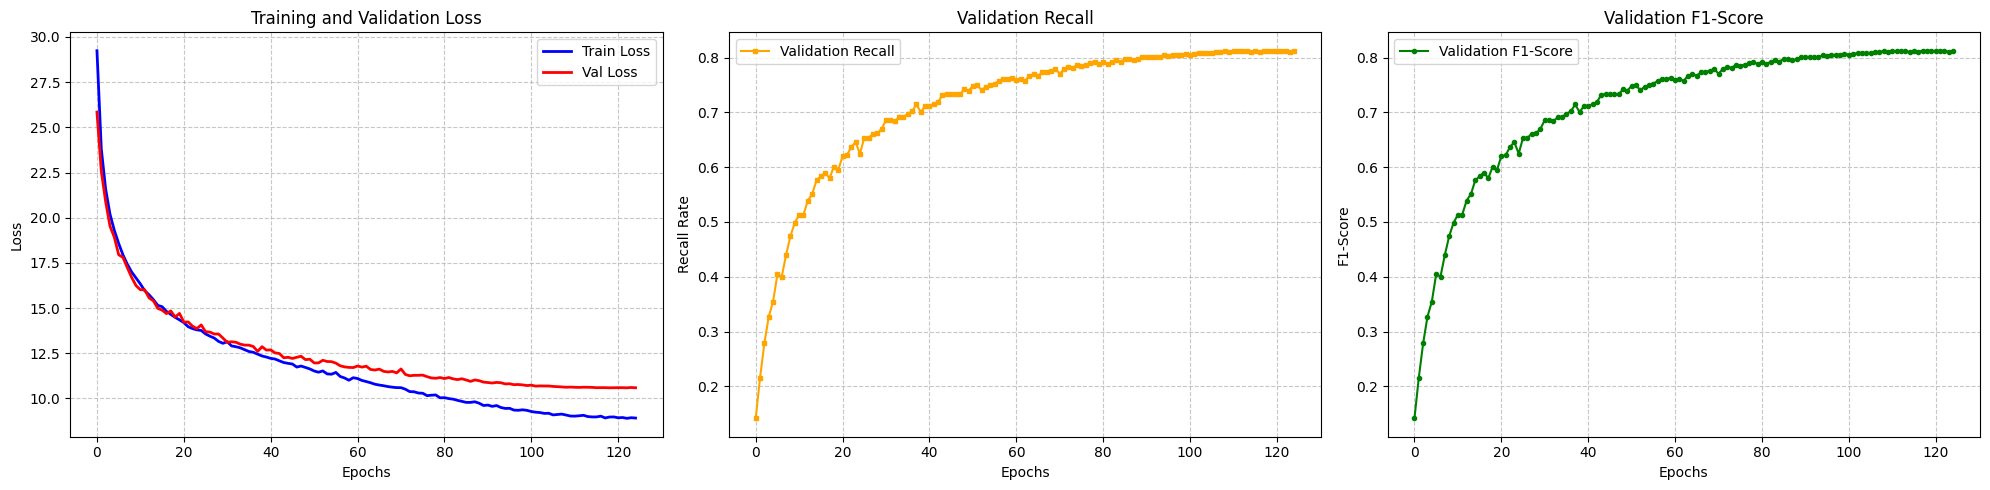

In [6]:
# ==========================================
# 6. กราฟสรุปผลการเทรน (Loss, Recall, F1-Score)
# ==========================================
import matplotlib.pyplot as plt

# สร้างพื้นที่วาดกราฟขนาดใหญ่ แถวเดียว 3 ช่อง
plt.figure(figsize=(20, 5))

# กราฟที่ 1: Loss
plt.subplot(1, 3, 1)
plt.plot(history_hand['t_loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history_hand['v_loss'], label='Val Loss', color='red', linewidth=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# กราฟที่ 2: Recall
plt.subplot(1, 3, 2)
plt.plot(history_hand['v_recall'], label='Validation Recall', color='orange', marker='s', markersize=3)
plt.title('Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall Rate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# กราฟที่ 3: F1-Score
plt.subplot(1, 3, 3)
plt.plot(history_hand['v_f1'], label='Validation F1-Score', color='green', marker='o', markersize=3)
plt.title('Validation F1-Score')
plt.xlabel('Epochs')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

📸 ให้ AI ทดลองทายโครงกระดูกมือ จากภาพที่ไม่เคยเห็น (Validation Set)...


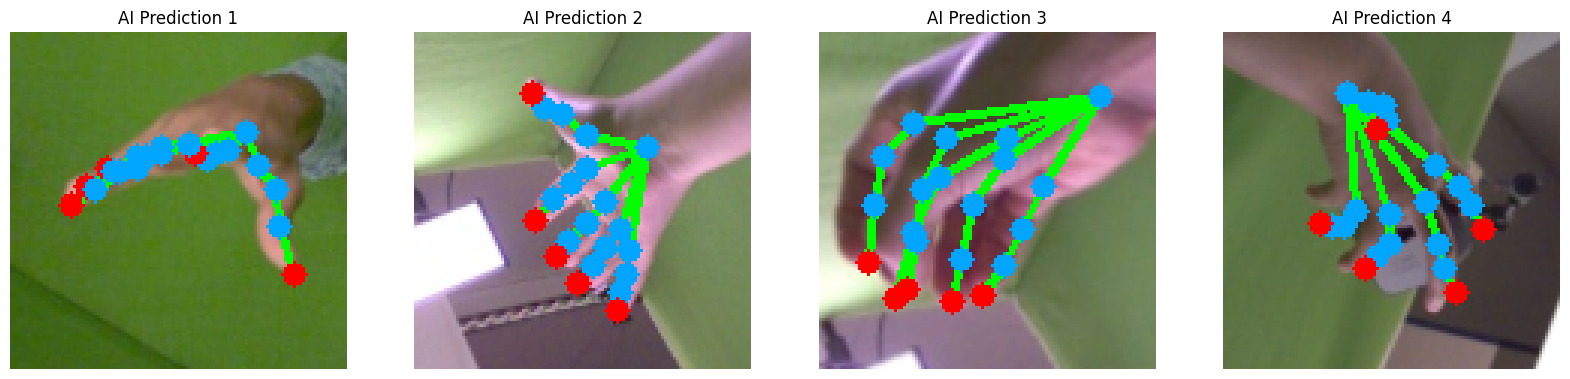

In [7]:
# ==========================================
# 7. ทดสอบโมเดลกับภาพจริง (Visualizing AI Predictions)
# ==========================================
import matplotlib.pyplot as plt
import torch
import cv2
import random
import numpy as np

def visualize_hand_predictions(model, dataset, num_samples=4):
    print("📸 ให้ AI ทดลองทายโครงกระดูกมือ จากภาพที่ไม่เคยเห็น (Validation Set)...")

    model.eval()
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))

    # เส้นเชื่อมข้อต่อกระดูก 21 จุดของ MediaPipe/FreiHAND
    connections = [
        (0,1), (1,2), (2,3), (3,4),        # หัวแม่มือ
        (0,5), (5,6), (6,7), (7,8),        # นิ้วชี้
        (0,9), (9,10), (10,11), (11,12),   # นิ้วกลาง
        (0,13), (13,14), (14,15), (15,16), # นิ้วนาง
        (0,17), (17,18), (18,19), (19,20)  # นิ้วก้อย
    ]

    with torch.no_grad():
        for i in range(num_samples):
            idx = random.randint(0, len(dataset)-1)
            img_tensor, _, raw_crop, _ = dataset[idx]

            img_input = img_tensor.unsqueeze(0).to(device)
            # ดึงพิกัดที่ AI ทายออกมา
            pred_kpts = model(img_input).squeeze(0).cpu().numpy().reshape(21, 2)

            h, w, _ = raw_crop.shape
            out_img = raw_crop.copy()
            kpts_pixel = (pred_kpts * [w, h]).astype(int)

            # วาดเส้นโครงกระดูก (สีเขียว)
            for (u, v) in connections:
                cv2.line(out_img, tuple(kpts_pixel[u]), tuple(kpts_pixel[v]), (0, 255, 0), 2)

            # วาดจุดข้อต่อ (ปลายนิ้วสีแดง, ข้อต่ออื่นสีฟ้า)
            fingertips = [4, 8, 12, 16, 20]
            for idx_pt, pt in enumerate(kpts_pixel):
                color = (255, 0, 0) if idx_pt in fingertips else (0, 165, 255)
                cv2.circle(out_img, tuple(pt), 4, color, -1)

            axes[i].imshow(out_img)
            axes[i].axis('off')
            axes[i].set_title(f"AI Prediction {i+1}")

    plt.show()

# เรียกใช้งานฟังก์ชันวาดรูปทายผล
visualize_hand_predictions(export_model, val_hand_dataset, num_samples=4)